In [1]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import scipy
from scipy.stats import binned_statistic
%config InlineBackend.figure_format='retina'

In [2]:
import h5py
f = h5py.File("C:/Users/havef/OneDrive/Desktop/Astro/sample_2e7_design_precessing_higherordermodes_3detectors.h5", 'r')

In [3]:
lenght = list(f.keys())
lenght

['chi1x',
 'chi1y',
 'chi1z',
 'chi2x',
 'chi2y',
 'chi2z',
 'dec',
 'det',
 'iota',
 'mtot',
 'psi',
 'q',
 'ra',
 'snr',
 'z']

in order to make the dataset analizable on a normal computer, i need to downsample the statistics

In [4]:
one_every = 5000  #1/precision of downloampled data
size = np.size(f[lenght[0]]) / one_every 

#create data array
data = np.zeros((int(size), np.size(lenght)))


In [5]:
for i in range (np.size(lenght)):
    data[:, i] = f[lenght[i]][::one_every]   

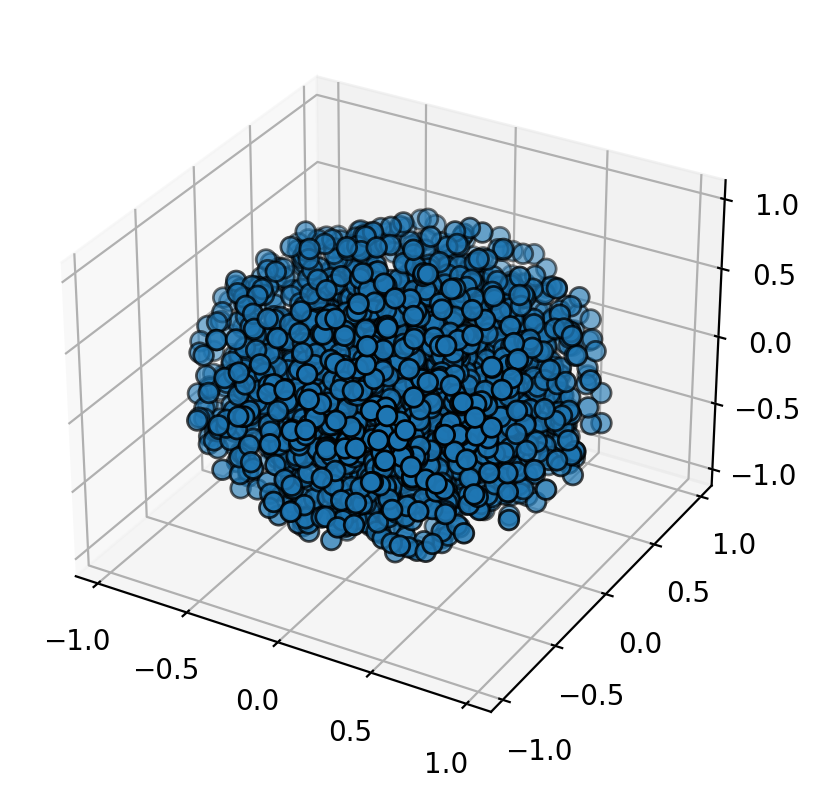

In [6]:
ax = plt.subplot(projection='3d')
ax.scatter3D(data[:, 0], data[:, 1],  data[:, 2] , 
                 s=50, cmap='spring', edgecolor='k')


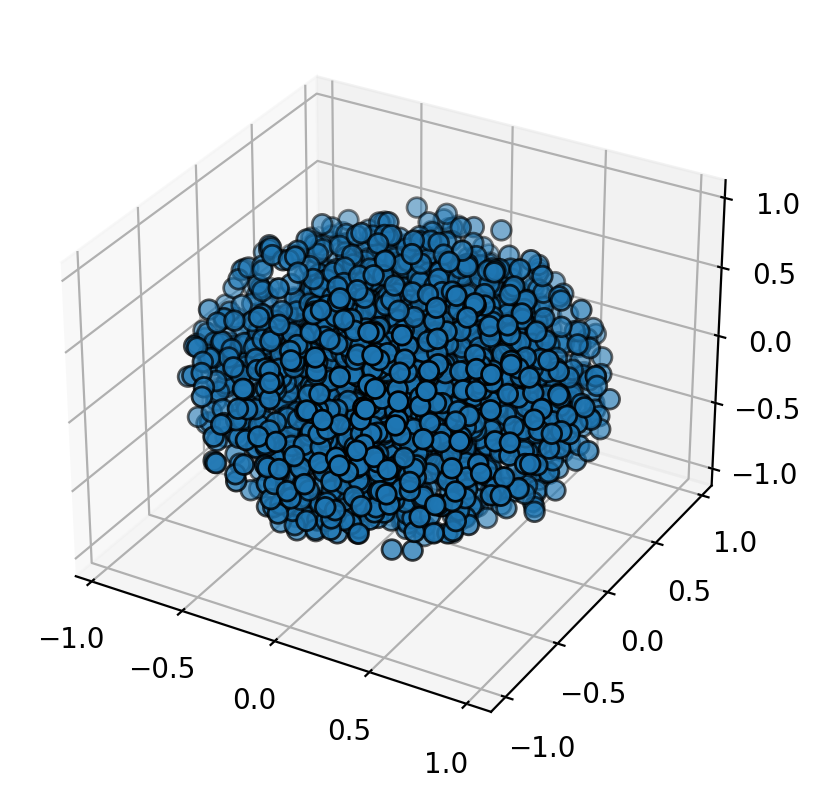

In [7]:
ax2 = plt.subplot(projection='3d')
ax2.scatter3D(data[:, 3], data[:, 4],  data[:, 5] , s=50, cmap='spring', edgecolor='k')
                 

In [34]:
ra = data[: , 12]
dec = data[: , 6]
det = data[: , 7]
snr = data[: , 13]
q = data[: , 11]
psi = data[: , 10]
mtot=data[: , 9]
iota = data[: , 8]
redshift = data[:, 14]


In [9]:
#creo array label
labels= np.zeros((np.size(data[:,0])))
for i in range (np.size(data[:,0])):
    if (snr[i] > 12):
        labels[i] = 1


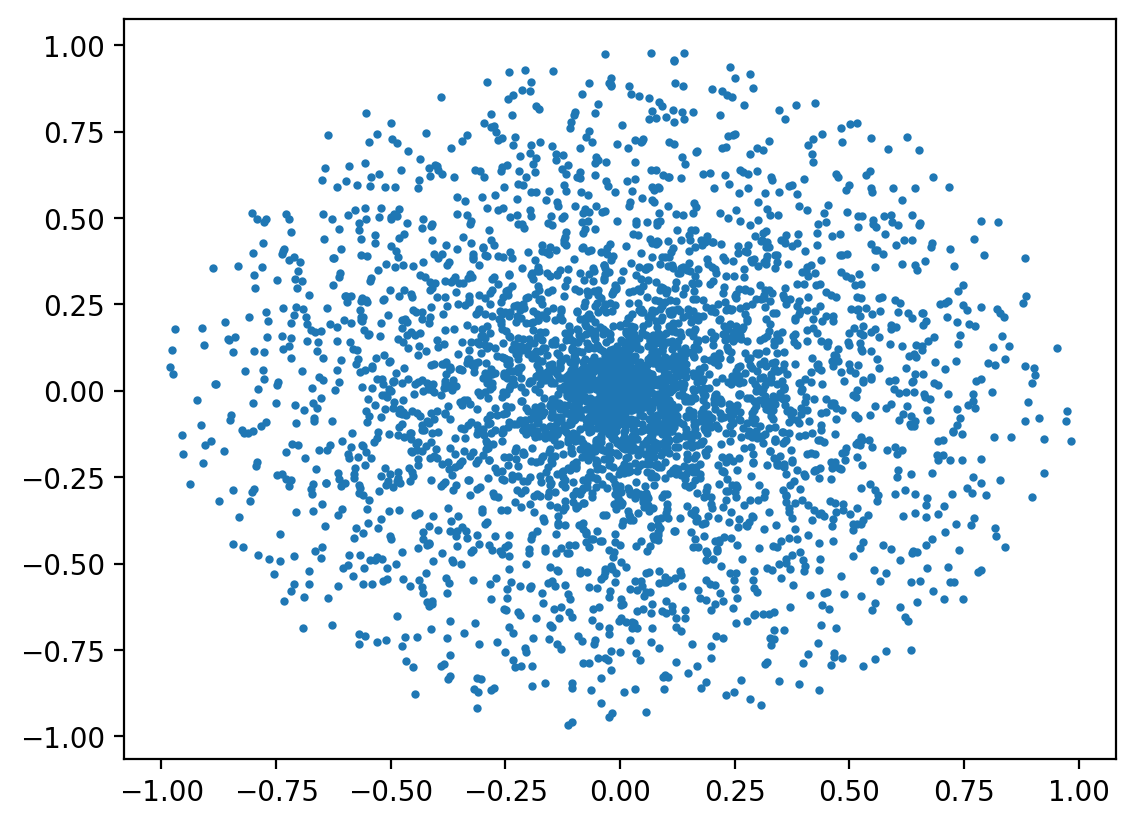

In [43]:
plt.scatter(data[:,0], data[:,1], s=4) 
plt.show()

##### now it's time to classify, but first i need some dimensionality reduction to find a optimal plane

In [54]:
from astroML.classification import GMMBayes
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

let's divide the dataset with TSNE!

In [47]:
isomap_data = np.column_stack((iota, redshift, q))

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


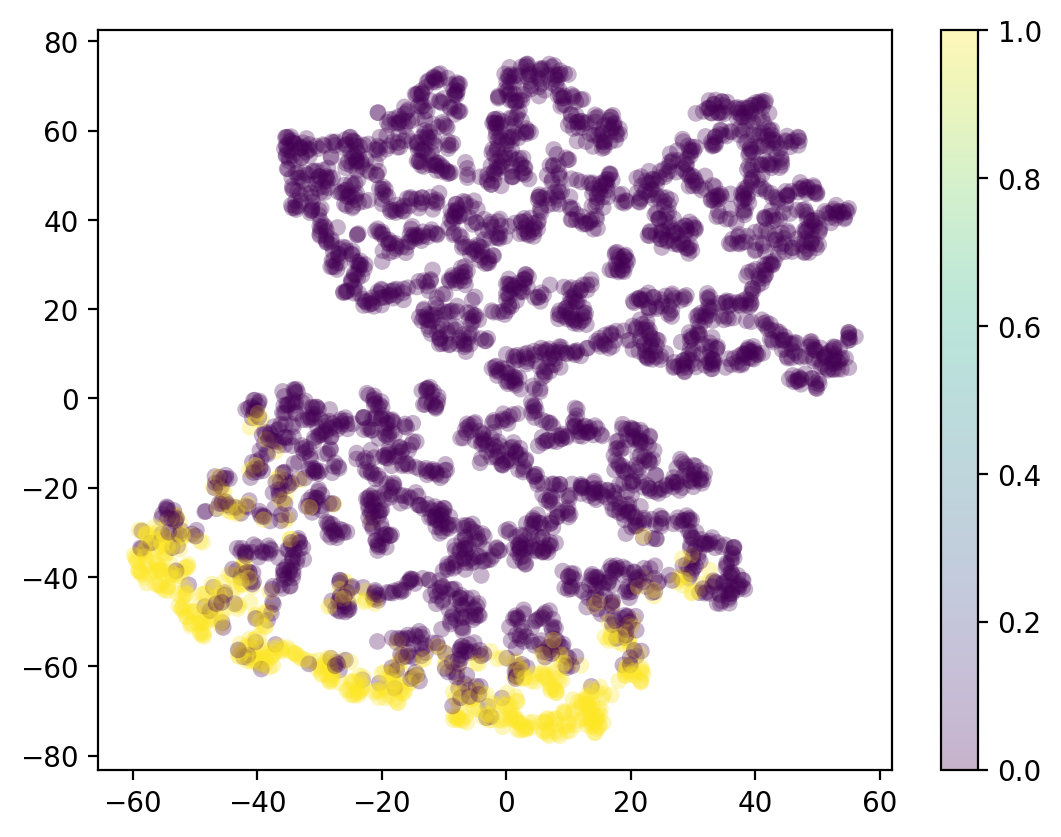

In [48]:
from sklearn.manifold import Isomap
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,learning_rate=200)
X_reduced = tsne.fit_transform(isomap_data)

plt.scatter(X_reduced[:,0],X_reduced[:,1], 
            c=labels, cmap="viridis", alpha=0.3, 
            edgecolor="None")
plt.colorbar()

In [55]:
(X_train, X_test), (y_train, y_test) = split_samples(X_reduced, labels, [0.75, 0.25],random_state=0)
                                                     
predictions = []  #creating predictions array
classifiers = []

N_tot = len(labels)
N_st = np.sum(labels == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr
Ncolors = np.arange(1, X_reduced.shape[1] + 1)

#computing the classification by cycling over dimensions
for i in range(np.size(X_reduced[0,:])):
    #clf = SVC(kernel='rbf',  C=100, probability=True) #using Support vector machines
    
    clf = BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=100, 
    bootstrap=True, random_state=42, n_jobs=-1) #using bagged decision tree
    
    clf.fit(X_train[:, :(i+1)] , y_train)   #fitting 
    
    classifiers.append(clf) #filling classifiers array
    predictions.append(clf.predict(X_test[:,:(i+1)]))   #filling the predictions array


    completeness, contamination = completeness_contamination(predictions, y_test) #computing completeness and contamination

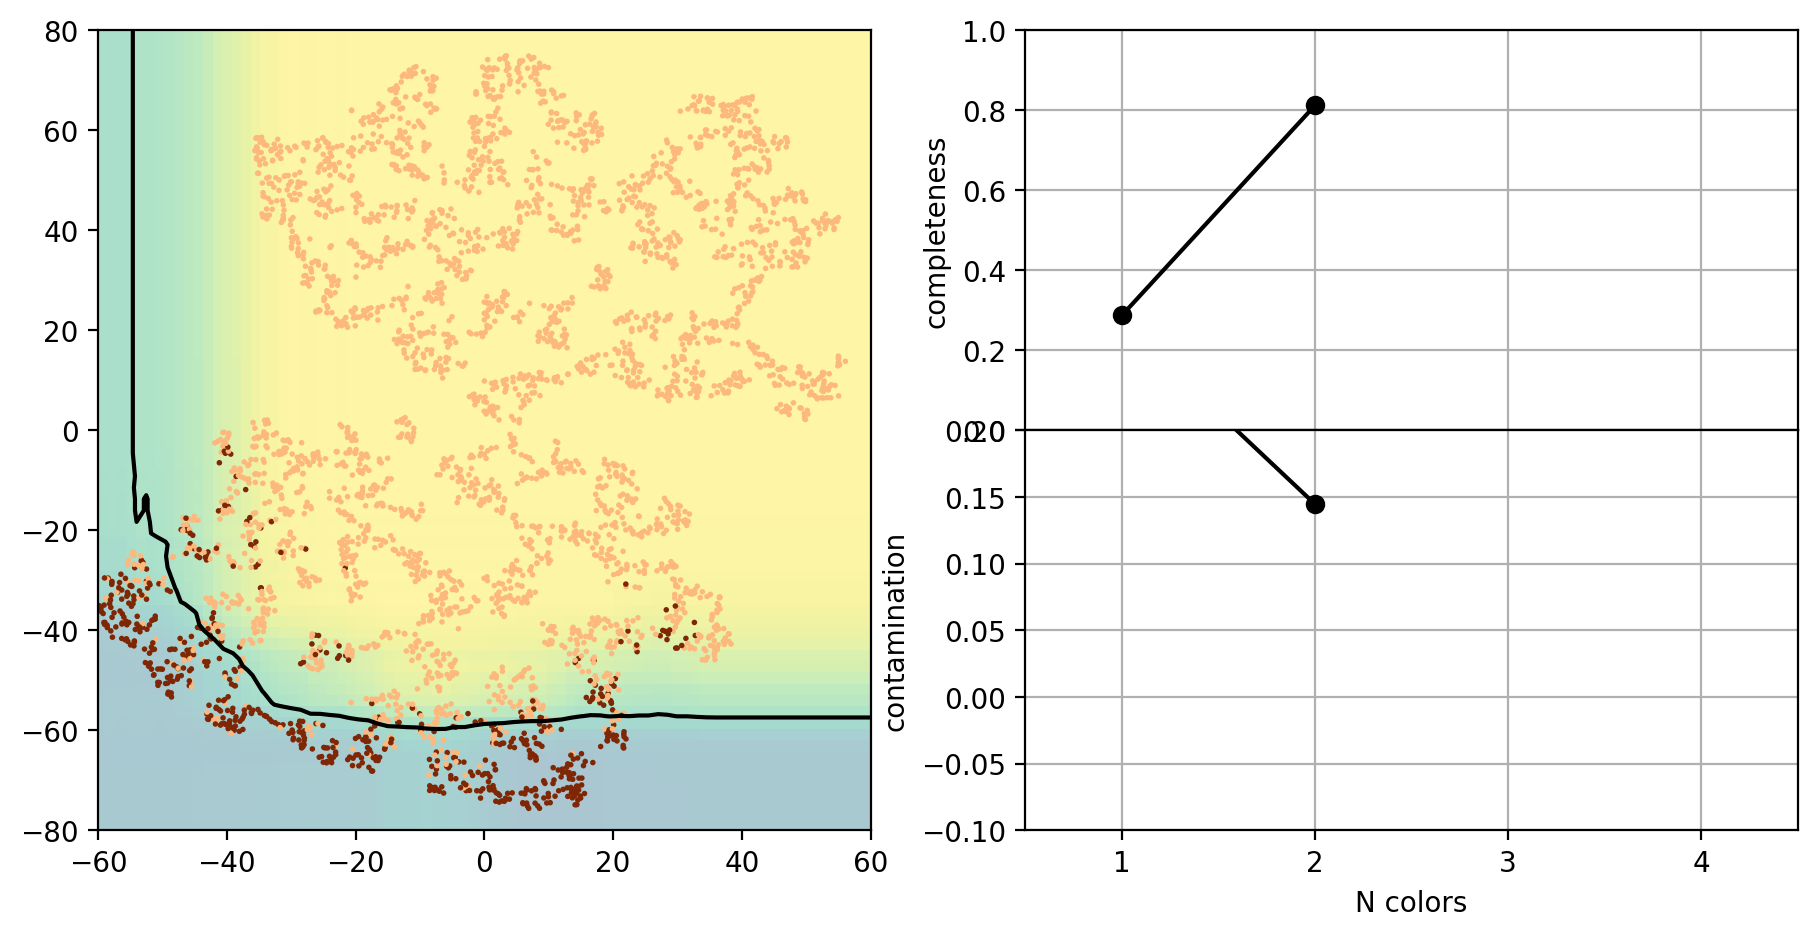

In [56]:
# Compute the decision boundary
clf = classifiers[1]
xlim = (-60, 60)
ylim = (-80, 80)


xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 81),
                     np.linspace(ylim[0], ylim[1], 71))

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z[:, 1].reshape(yy.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X_reduced[-N_plot:, 0], X_reduced[-N_plot:, 1], c=labels[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',cmap='viridis_r', zorder=1,extent=xlim + ylim, alpha = 0.4)
        #plt.cm.binary
im.set_clim(0, 1.5)
ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)


# Plot completeness vs Ncolors
ax = plt.subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.0, 1.0)
ax.grid(True)

# Plot contamination vs Ncolors
ax = plt.subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 0.2)
ax.grid(True)

i achieved a completeness of 

In [57]:
completeness[1]

0.8125

and a contamination of 

In [58]:
contamination[1]

0.14473684210526316